In [2]:
import glob                                                                                                
import pandas as pd
import geopandas as gp
import seaborn as sns
import matplotlib.pyplot as plt

files = glob.glob("data/scrap-pagebogota-*.csv")                       
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

## 1. Data Overview

The dataset comprises approximately 70,000 residential property listings scraped from Bogotá, each described by 26 features including built area (m²), number of bedrooms, socioeconomic stratum, parking availability, and listing price, among others.

The goal of this notebook is to perform an Exploratory Data Analysis (EDA) to assess data quality, understand feature distributions, and prepare the dataset for feature engineering and modeling. Location-based signals such as Points of Interest (POIs) will also be incorporated in subsequent stages.

In [3]:
df.columns

Index(['id', 'area_m2', 'cuartos', 'estrato', 'tipo', 'parqueaderos', 'banios',
       'piso', 'precio', 'precio_m2', 'precio_admin', 'vendedor',
       'tipo_vendedor', 'tipo_propiedad', 'barrio', 'ciudad', 'lat', 'lon',
       'direccion', 'id_propiedad', 'creado', 'publicado', 'actualizado',
       'antiguedad', 'descripcion', 'url'],
      dtype='object')

## 2. Data Quality

### 2.1 Area (m²) — Bounds Enforcement

According to CAMACOL's Economic Report No. 121 *(Internacionalización de la Vivienda, CAMACOL, 2024)*, the median built area of sold residential units in Bogotá ranges between 60–70 m². Values above 5,000 m² (~200 rows) were identified as outliers and removed, as they likely represent data entry errors or non-residential listings rather than typical housing stock.

> Source: [Informe Económico No. 121 — CAMACOL](https://camacol.co/sites/default/files/descargables/Informe%20Econ%C3%B3mico%20121.pdf)

Additionally, Colombian urban regulation establishes a minimum habitable area of 18 m² for residential units (non-VIS/VIP category). Listings below this threshold do not represent valid residential units and were also removed.

> Source: [Decreto 462 de 2024 — Alcaldía de Bogotá](https://www.alcaldiabogota.gov.co/sisjur/normas/Norma1.jsp?i=139499)

In [4]:
df = df[(df['area_m2'] >= 18) & (df['area_m2'] <= 5000)]

## 3. Feature Selection — Dropping Irrelevant Columns

The following columns carry no predictive signal for price estimation and are removed prior to modeling:

- **`vendedor` / `tipo_vendedor`** — broker identity and type introduce noise and potential data leakage.
- **`tipo`** — single-value column (`venta` across all records), adding no information.
- **`creado`, `publicado`, `actualizado`** — internal timestamps from the data source, not intrinsic properties of the unit.
- **`url`** — listing identifier with no predictive value.

> The `id` column is retained as a join key for merging imputed values back into the dataset.

In [5]:
# The `id` column serves as the join key to merge imputed values back into the original dataset.

df = df.drop(columns=['vendedor', 'tipo_vendedor','id_propiedad','creado','publicado','actualizado','url','tipo'])

## 4. Property Type — Recategorization

The `tipo_propiedad` column contains 11 distinct categories in the raw data (casa, apartamento, apartaestudio, oficina, lote, bodega, etc.). The dataset is restricted to residential units only, excluding commercial and non-standard listings.

Units categorized as `apartaestudio` (studio/loft) are recategorized as `apartamento`, as they share the same structural characteristics. This yields two final classes: **house** and **apartment**.

This decision is consistent with the properties microservice domain model, which enforces a `PropertyType` enum with exactly two values (`house`, `apartment`), ensuring alignment between the training data distribution and the production system's data contract.

In [6]:
df['tipo_propiedad'].unique()

array(['apartamento', 'casa', 'apartaestudio', 'oficina', 'consultorio',
       'local', 'habitacion', 'casa lote', 'lote', 'casa campestre',
       'bodega', 'finca', 'edificio', 'cabaña'], dtype=object)

In [7]:
correcciones = {
    'apartaestudio': 'apartamento',                                                                        
    'casa lote': 'casa',
    'casa campestre': 'casa',                                                                              
    'cabaña': 'casa',
}                                                                                                          
                                                                                                             
df['tipo_propiedad'] = df['tipo_propiedad'].replace(correcciones)
df = df[df['tipo_propiedad'].isin(['apartamento', 'casa'])]

<Axes: xlabel='tipo_propiedad', ylabel='count'>

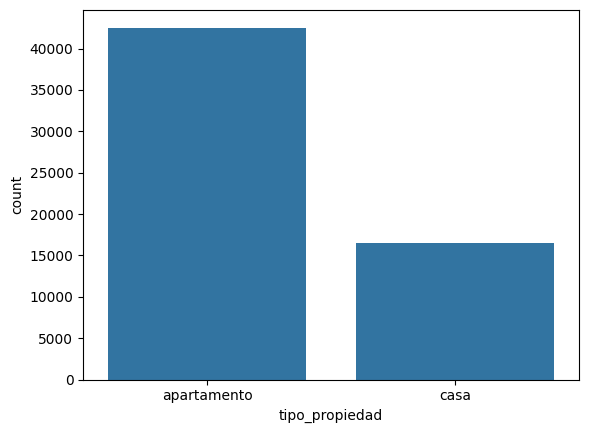

In [8]:
sns.countplot(df, x="tipo_propiedad")

(0.0, 500.0)

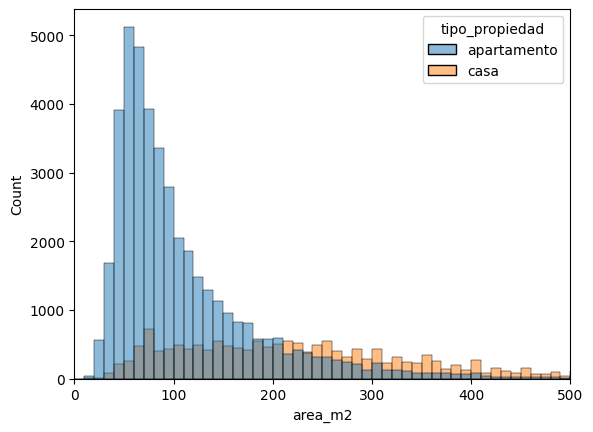

In [9]:
sns.histplot(data=df, x="area_m2", bins=100, binrange=(0, 1000), hue='tipo_propiedad')
plt.xlim(0, 500)

### 4.1 Distribution

The dataset is heavily skewed towards apartment listings, reflecting Bogotá's urban density — a city where multi-family buildings dominate, particularly in consolidated neighborhoods.

Regarding built area, the majority of residential units fall below 100 m², consistent with the CAMACOL benchmark discussed in section 2.1. Apartments concentrate within this range by design, while houses may exceed it due to multi-floor configurations that accumulate total built area across levels.

## 5. Stratum (Estrato) Imputation — Spatial K-Nearest Neighbors

The `estrato` column presents missing or ambiguous values encoded as `"especificar"`. These cannot be reliably imputed using statistical measures alone, as socioeconomic stratum in Bogotá is a spatially defined administrative classification — each city block is assigned a stratum by the local government.

To preserve this spatial semantics, we apply a K-Nearest Neighbors approach using geographic coordinates as the proximity metric. For each listing with a missing stratum, we identify its *k* nearest neighbors among listings with a known stratum and assign the most frequent value (mode) among them.

This is valid because stratum boundaries in Bogotá are spatially contiguous — nearby properties are highly likely to share the same stratum.

In [10]:
df = gp.GeoDataFrame(df, geometry=gp.points_from_xy(df['lat'],df['lon']), crs="EPSG:4326").to_crs(epsg=3116)
impute_stratum = df.loc[(df['estrato']=='especificar') | (df['estrato']=='0')]

df = df[(df['estrato'] != 'especificar') & (df['estrato'] != '0')]

geopanads_join = gp.sjoin_nearest(impute_stratum,df,max_distance=500,distance_col="distances")

geopanads_join[['id_left','estrato_left','geometry','id_right','estrato_right','geometry','distances']]

,id_left,estrato_left,geometry,id_right,estrato_right,geometry,distances
260,90ff2222-1992-4706-a49a-50cc4dbc2857,0,POINT (2756493.588 -9155522.067),bc31654f-0786-463c-98cc-6afa0a749906,3,POINT (2756493.588 -9155522.067),0.0
260,90ff2222-1992-4706-a49a-50cc4dbc2857,0,POINT (2756493.588 -9155522.067),efe5c125-2617-41f3-bf6b-de95f4c18e39,3,POINT (2756493.588 -9155522.067),0.0
260,90ff2222-1992-4706-a49a-50cc4dbc2857,0,POINT (2756493.588 -9155522.067),7f5f0757-b2ed-426c-8d7e-42e9418b60e2,3,POINT (2756493.588 -9155522.067),0.0
260,90ff2222-1992-4706-a49a-50cc4dbc2857,0,POINT (2756493.588 -9155522.067),f5b71918-ae97-476a-8152-939f6c09ae88,3,POINT (2756493.588 -9155522.067),0.0
260,90ff2222-1992-4706-a49a-50cc4dbc2857,0,POINT (2756493.588 -9155522.067),7f5f0757-b2ed-426c-8d7e-42e9418b60e2,3,POINT (2756493.588 -9155522.067),0.0
...,...,...,...,...,...,...,...
67327,fa897f4f-929d-482e-bc0b-1768ac6603f1,0,POINT (13669113.61 491767.534),86eeb00e-dd66-4947-b3f9-d41b84f08ac4,5,POINT (13669113.61 491767.534),0.0
67327,fa897f4f-929d-482e-bc0b-1768ac6603f1,0,POINT (13669113.61 491767.534),aaa2b2b9-a48c-4dcd-974c-9e0a2b296346,3,POINT (13669113.61 491767.534),0.0
67327,fa897f4f-929d-482e-bc0b-1768ac6603f1,0,POINT (13669113.61 491767.534),994e44ae-5f5a-490e-87e6-55f1f57b5fd2,3,POINT (13669113.61 491767.534),0.0
67812,76166475-3157-4586-979e-eb8f9dac6e89,0,POINT (2769152.5 -9153829.036),ab388296-b89f-4d2a-aab4-43b26f7cec05,6,POINT (2769152.5 -9153829.036),0.0


### 5.1 Geographic Outlier Removal

One listing was found with coordinates pointing to Mexico (`lat=24.05`, `lon=-104.68`), likely a data entry error from the scraping source. When projected to EPSG:3116 (MAGNA-SIRGAS Colombia), this produces an `Infinity` geometry. Since the dataset is restricted to Bogotá, this record is dropped prior to spatial processing.

In [11]:
i = df[~df.geometry.is_valid | df.geometry.is_empty | df.geometry.isna()].index
df = df.drop(i)

### 5.2 Exploratory Spatial Join

Some properties report a distance of 0 meters to their nearest neighbor. This is expected — apartments within the same residential complex share identical coordinates, as geocoding resolves to the building entrance rather than the individual unit. Since all units in a complex belong to the same stratum by definition, a distance of 0 is a valid spatial signal confirming stratum homogeneity at the building level.

However, `sjoin_nearest` does not support a `k` parameter — it only returns multiple results when neighbors are exactly equidistant, limiting its use for majority-vote imputation. To retrieve the top-*k* nearest neighbors, we switch to scikit-learn's `BallTree`, which allows explicit control over *k* and computes distances efficiently over projected metric coordinates.

In [12]:
import numpy as np
from sklearn.neighbors import BallTree

# Get coordinates in meters to fit the tree
 
coords = np.array([(geom.x, geom.y) for geom in df.geometry])
tree = BallTree(coords, leaf_size=5)

# Impute the missing stratum with the 10 Nearest Neighborhood

query_coords = np.array([(geom.x, geom.y) for geom in impute_stratum.geometry])                             
distances, indices = tree.query(query_coords, k=10)

for i, idx in enumerate(indices):                                                                           
    vecinos = df.iloc[idx]                                                                                  
    estrato_imputado = vecinos['estrato'].mode()[0]                                                         
    impute_stratum.iloc[i, impute_stratum.columns.get_loc('estrato')] = estrato_imputado

# Join the dataframes to get the original one with all missing stratum data corrected

df = pd.concat([df, impute_stratum])

### 5.3 Stratum vs. Area — Post-Imputation Analysis                                                         

Following the spatial KNN imputation, the relationship between built area and socioeconomic stratum becomes clearly visible in the data.
                                                                                                            
For **apartments**, a strong positive correlation emerges: units above 100 m² tend to belong to stratum 4, 5, and 6, which correspond to premium zones of the city such as Rosales, Chicó, and Nórte. This is consistent with Bogotá's urban density patterns, where larger apartments are typically found in high-end developments.
                                                                                                            
For **houses**, however, this trend does not hold. A house with 300 m² is not necessarily located in a premium zone — multi-floor construction allows houses in any stratum to accumulate total built area across levels, decoupling area from location quality in a way that does not occur in apartment towers.
                                                                                                            
This asymmetry reinforces the decision to model houses and apartments separately where possible, and to treat `piso` as two semantically distinct features (`num_pisos` for houses, `piso_torre` for apartments).

Text(0.5, 1.0, 'Casa')

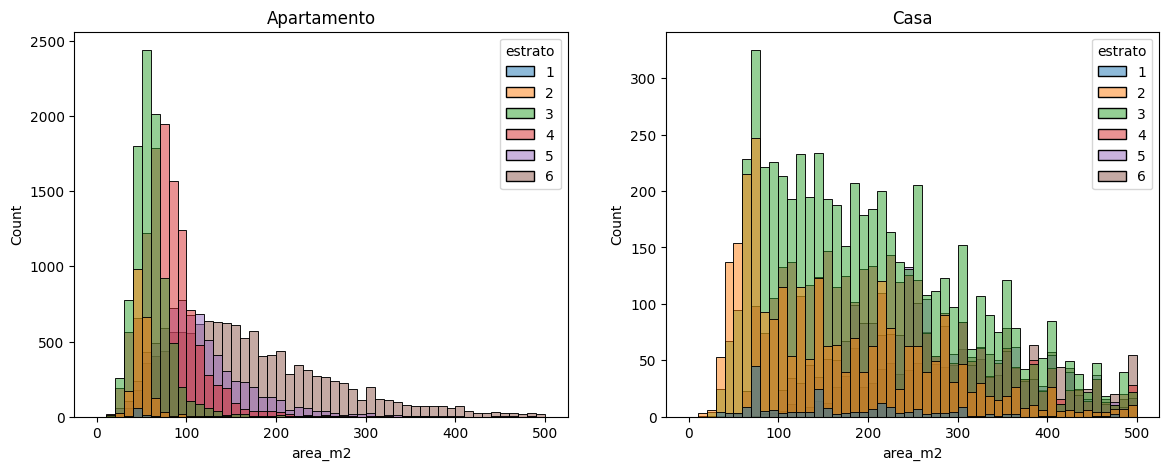

In [13]:
df = df[df['estrato'].notnull()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 

orden_estrato = sorted(df['estrato'].unique())
                                                                                                              
sns.histplot(data=df[df['tipo_propiedad']=='apartamento'], x="area_m2", hue="estrato",hue_order=orden_estrato, bins=50, binrange=(0, 500), ax=axes[0])
axes[0].set_title("Apartamento")                                                                            
                
sns.histplot(data=df[df['tipo_propiedad']=='casa'], x="area_m2", hue="estrato",hue_order=orden_estrato,bins=50, binrange=(0, 500), ax=axes[1])
axes[1].set_title("Casa")

### 5.4 Anomalous Records After Imputation

However, the imputation is not perfect — some records remain anomalous after the KNN correction. Apartments with over 200 m² assigned to stratum 1 or 2 are physically implausible given Bogotá's urban structure, and likely reflect corrupted coordinates in the source data that caused the spatial join to match against incorrect neighbors. These records are candidates for removal prior to modeling.

In [14]:
df[(df['area_m2'] > 200) & (df['estrato'].astype(str).isin(['1', '2'])) & (df['tipo_propiedad']=='apartamento')]

,id,area_m2,cuartos,estrato,parqueaderos,banios,piso,precio,precio_m2,precio_admin,tipo_propiedad,barrio,ciudad,lat,lon,direccion,antiguedad,descripcion,geometry
14905,31649c71-c769-4539-b579-86d40e58b459,230,3,1,3,5,2°,1800000000,7826086.96,530000.0,apartamento,los-rosales,bogota,4.661255,-74.047389,KR 4 # 81 - 30,16 a 30 años,⭕⭕VENDO ESTA BELLEZA DE APTO.- REMODELADO TOTA...,POINT (2768249.658 -9153430.408)
15809,b0990822-f0af-4212-9492-3e7697c72f08,287,3,1,2,2,1°,1520000000,5296167.25,1450000.0,apartamento,los-rosales,bogota,4.651460,-74.048820,Calle 72A Bis #1-10,más de 30 años,Excelente townhouse de conservación arquitect...,POINT (2768023.98 -9153158.374)
16774,e381615b-9914-452c-840d-c5d789c26b44,674,4,2,Sin especificar,5,2°,1950000000,2893175.07,0.0,apartamento,el-palmar,bogota,4.713987,-74.140717,CALLE 53 N\u00b073A-99,9 a 15 años,"VENTA O PERMUTA CASA RENTABLE, COMERCIAL EN EN...",POINT (2757998.018 -9157258.525)
17702,250636a7-6edb-4bc0-b1e3-ba23ba4d49f5,302,4,1,2,6,Sin especificar,3000000000,9933774.83,0.0,apartamento,los-rosales,bogota,4.662007,-74.045792,Transversal 1 # 84A\u2013 07,más de 30 años,Este hermoso apartamento ha sido remodelado y ...,POINT (2768435.803 -9153416.331)
18613,be7cd5ca-d6f7-43a1-b550-9bdcdd6870ea,364,4,1,4,4,Sin especificar,3000000000,8241758.24,2154864.0,apartamento,santa-ana,bogota,4.688167,-74.031709,Carrera 4 # 109 - 42,9 a 15 años,OBRA DE ARTE ARQUITECTONICA EN VENTA CON SECUE...,POINT (2770203.159 -9153902.619)
20777,eb1bde80-c8f9-4037-945a-253e8cd65c26,364,4,1,4,4,Sin especificar,3000000000,8241758.24,2154864.0,apartamento,santa-ana,bogota,4.688000,-74.032000,Carrera 4 # 109 - 42,9 a 15 años,OBRA DE ARTE ARQUITECTONICA EN VENTA CON SECUE...,POINT (2770169.022 -9153904.242)
24809,5d7bcfe1-4d52-4057-b4dc-244e9cec5527,210,6,1,1,4,Sin especificar,720000000,3428571.43,0.0,apartamento,san-luis,bogota,4.650000,-74.069000,Carrera 19A # 61B - 45 Piso 1,más de 30 años,Luque Ospina ofrece en venta propiedad dividid...,POINT (2765724.515 -9153587.515)
33566,8e04a4a5-1bd2-4e1f-aa35-ad1d056d2f2c,312,3,2,Sin especificar,2,Sin especificar,300000000,961538.46,0.0,apartamento,bosques-de-mariana,bogota,4.696333,-74.124809,cra 107B # 70-79.,9 a 15 años,Casa de 3x12 cuatro niveles 3 alcobas 2 baños ...,POINT (2759689.975 -9156338.463)
38457,6df80b31-60a6-4d52-b54b-e7c6c27fd7d5,238,3,1,2,2,Sin especificar,1300000000,5462184.87,1300000.0,apartamento,samper,bogota,4.615410,-74.069592,CARRERA 13 27- 98,más de 30 años,Tengo el gusto de presentarles para la venta a...,POINT (2765433.574 -9152523.68)
43036,188b82e9-4b80-4d27-9d7b-abc6080dd4dc,238,2,1,2,3,13°,1300000000,5462184.87,1300000.0,apartamento,samper,bogota,4.615534,-74.069725,Carrera 13 #28-8,más de 30 años,"Amplio apartamento, para remodelar, zona socia...",POINT (2765419.346 -9152530.676)


## 6. Feature Imputation — Domain-Driven Rules                                                              

Before proceeding to the EDA, remaining missing or implausible values are addressed  through domain-driven imputation rules rather than purely statistical methods.
                                                                                                            
Socioeconomic and physical constraints in Bogotá's housing market allow us to define hard rules grounded in real-world knowledge. For example:
                                                                                                            
- **Bedrooms (`cuartos`)**: units below 35 m² cannot physically accommodate more than one bedroom — all such listings are set to 1 bedroom regardless of the recorded value.

- **Bathrooms (`banios`)**: imputed using the median grouped by `estrato` and `tipo_propiedad`, as bathroom count correlates strongly with both socioeconomic stratum and property type.                                                                                
                                                                                                            
This hybrid approach — domain rules for structural constraints, statistical imputation for the remainder — reduces the risk of introducing bias while keeping the dataset as complete as possible prior to feature engineering.

In [15]:
correcciones = {
    'Sin especificar': pd.NA,
    0: pd.NA
}

for column in ['cuartos','banios','piso','parqueaderos']:
    df[column] = df[column].replace(correcciones)

df.isnull().sum()

id                    0
area_m2               0
cuartos             500
estrato               0
parqueaderos      13334
banios             1405
piso              18806
precio                0
precio_m2             0
precio_admin          0
tipo_propiedad        0
barrio                0
ciudad                0
lat                   0
lon                   0
direccion             9
antiguedad            0
descripcion           0
geometry              0
dtype: int64

### 6.1 Bedrooms (`cuartos`) — Zero Value Treatment                                                         

The `cuartos` column contains records with a value of 0, which is physically impossible for a residential unit — by definition, every dwelling must have at least one habitable room. These zero values likely represent missing data encoded as 0 by the scraping source rather than a true count.
                                                                                                            
Listings with `cuartos = 0` are inspected by area range to determine the most plausible imputation: units are assigned the minimum of 1 bedroom, with further adjustments applied based on the area thresholds defined in section 6.

(0.0, 500.0)

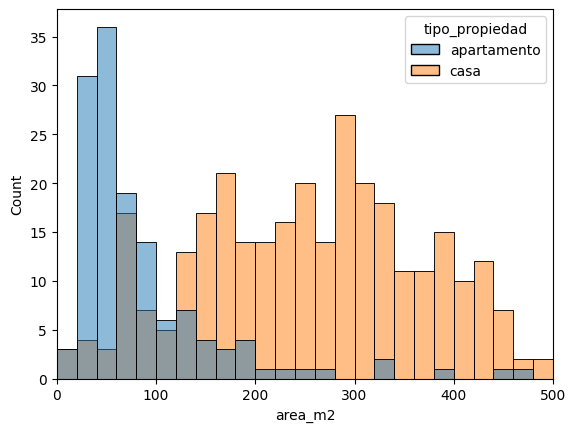

In [16]:
sns.histplot(data=df[df['cuartos'].isnull()], x="area_m2", bins=50, binrange=(0, 1000), hue='tipo_propiedad')
plt.xlim(0, 500)

### 6.1.1 Area-Based Bedroom Imputation

We can bucketize the area into ranges and impute the number of bedrooms using the median within each bucket. This is preferable to a global median imputation because bedroom count is physically constrained by area — a studio-sized unit and a large house should not receive the same imputed value. By computing the median within each area segment, the imputation reflects the actual distribution of similarly-sized properties in the dataset rather than a single central tendency across all unit sizes.

In [17]:
# Set bins in order to get an aproximation of numer of bathrooms per m2
bins = [0, 35, 60, 90, 120, 200, 5000]

# Calculate the median of each bin
medianas = df.groupby(pd.cut(df['area_m2'], bins=bins), observed=True)['cuartos'].median()

# Replace the missing data according to his correspondent bin
mask = (df['cuartos'].isnull()) | (df['cuartos'] == 0)
df.loc[mask, 'cuartos'] = df.loc[mask, 'area_m2'].apply(lambda x: medianas[pd.cut([x], bins=bins)[0]])

### 6.2 Bathrooms (`banios`) — Median Imputation by Stratum and Property Type                               
                                                                                                              
Missing bathroom values are imputed using the median grouped by `estrato` and `tipo_propiedad`. Unlike bedrooms, bathrooms do not have a strict area-based constraint, but correlate strongly with socioeconomic stratum and property type — a stratum 6 apartment is far more likely to have 2+ bathrooms than a stratum 2 unit of similar size.

In [18]:
df["banios"] = pd.to_numeric(df["banios"], errors="coerce")
df.groupby(["estrato", "tipo_propiedad"]).agg({"banios": "median"})

banios
estrato tipo_propiedad        
1       apartamento        1.0
        casa               3.0
2       apartamento        1.0
        casa               3.0
3       apartamento        2.0
        casa               3.0
4       apartamento        2.0
        casa               3.0
5       apartamento        3.0
        casa               4.0
6       apartamento        3.0
        casa               5.0

In [19]:
mask = df['banios'].isnull()                                                                                
medianas_banios = df[~mask].groupby(["estrato", "tipo_propiedad"])['banios'].median()
                                                                                                            
df.loc[mask, 'banios'] = df.loc[mask].apply(                                                                
    lambda row: medianas_banios.get((row['estrato'], row['tipo_propiedad'])), axis=1                        
) 

### 6.3 Parking Spots (`parqueaderos`) — Median Imputation by Stratum and Property Type                     
                                                                                                              
Missing parking values are imputed using the median grouped by `estrato` and `tipo_propiedad`. Parking availability in Bogotá correlates strongly with socioeconomic stratum — higher strata developments typically include one or more dedicated parking spots as a standard amenity, while lower strata units rarely do.

In [20]:
df["parqueaderos"] = pd.to_numeric(df["parqueaderos"], errors="coerce")                                     
                                                                                                              
bins = [0, 35, 60, 90, 120, 200, 5000]                                                                      
df['area_bin'] = pd.cut(df['area_m2'], bins=bins)
                                                                                                            
mask = df['parqueaderos'].isnull()

# Remove estrato as some corrupted records appear

medianas_parqueaderos = df[~mask].groupby(
    ["tipo_propiedad", "area_bin"], observed=True                                                
)['parqueaderos'].median()                                                                                  

df.loc[mask, 'parqueaderos'] = df.loc[mask].apply(                                                          
    lambda row: medianas_parqueaderos.get((row['tipo_propiedad'], row['area_bin'])), axis=1
)                                                                                                           

df = df.drop(columns=['area_bin'])

### 6.4 Floor (`piso`) — Semantic Analysis                                                    
                                                                                                              
The `piso` column encodes two semantically different concepts depending on the property type:
                                                                                                            
- **Houses (`casa`)**: `piso` represents the total number of floors in the unit — a structural feature that correlates with total built area and capacity.

- **Apartments (`apartamento`)**: `piso` represents the floor level within a tower — a locational feature that correlates with price, as higher floors typically command a premium in Bogotá's market.                                                                               
                                                                                                            
Treating both under a single column would introduce noise by conflating two distinct signals. The column is therefore split into `num_pisos` (houses only) and `piso_torre` (apartments only), with NaN assigned where the concept does not apply.

(0.0, 10.0)

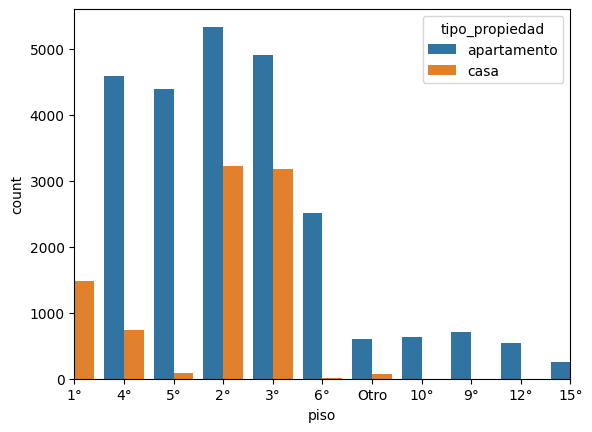

In [21]:
sns.countplot(df, x="piso", hue="tipo_propiedad")
plt.xlim(0, 10)

In [22]:
df['num_pisos'] = np.where(df['tipo_propiedad'] == 'casa', df['piso'], np.nan)                            
df['piso_torre'] = np.where(df['tipo_propiedad'] == 'apartamento', df['piso'], np.nan)

df = df.drop(columns=['piso'])

In [23]:
df[(df['piso_torre'].isnull()) & (df['tipo_propiedad'] == 'apartamento')]

,id,area_m2,cuartos,estrato,parqueaderos,banios,precio,precio_m2,precio_admin,tipo_propiedad,barrio,ciudad,lat,lon,direccion,antiguedad,descripcion,geometry,num_pisos,piso_torre
2,04d367ce-cb0c-4be6-a0e1-78cdf813d3d2,60,3,3,1.0,2.0,175000000,2916666.67,148800.0,apartamento,turingia-et.-ii,bogota,4.749566,-74.089924,Carrera 101 #151-33,9 a 15 años,"NHI-VENDE APARTAMENTO EN SUBA LA CAMPIÑA, en c...",POINT (2763989.728 -9157178.604),NaN,<NA>
9,358cbe8a-00ee-4a49-ab5f-22c95ddbc2b8,39,2,3,1.0,1.0,198000000,5076923.08,124000.0,apartamento,bosconia,bogota,4.649906,-74.145523,Calle 10B #81F-92,1 a 8 años,Espectacular apartamento con vista exterior de...,POINT (2757042.084 -9155383.777),NaN,<NA>
14,bbe53b79-74f5-4859-96a8-927194a60724,29,1.0,3,1.0,1.0,165000000,5689655.17,0.0,apartamento,la-cabana,bogota,4.674810,-74.098880,CARRERA 70 B No. 64 B - 24,1 a 8 años,"Gran Oportunidad, Se Vende Aparta Estudio con ...",POINT (2762493.916 -9155061.831),NaN,<NA>
19,7d68c53e-e0cd-4eb8-a505-276bb05d0e01,35,3,3,1.0,1.0,199999000,5714257.14,0.0,apartamento,engativa,bogota,4.695931,-74.100831,Cra. 81A #74-80,menor a 1 año,Cod. 37. ESPECTACULAR APARTAMENTO de 35M2 . Se...,POINT (2762408.192 -9155764.493),NaN,<NA>
25,5f2e4eb0-81aa-4b28-b1b0-012221e50f12,28,1,4,1.0,1.0,190000000,6785714.29,0.0,apartamento,modelia,bogota,4.665779,-74.126411,CARRERA 82 22D- 56,1 a 8 años,Aparta-estudio en edificio en el barrio Modeli...,POINT (2759312.163 -9155427.307),NaN,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66944,0e1ab8f3-bf5b-44c5-8fe4-50763d537bbf,104,3,5,2.0,3.0,550000000,5288461.54,0.0,apartamento,el-contador,bogota,4.720448,-74.044196,Cra 16134-81,sin especificar,Apartamento en perfecto estado en venta remode...,POINT (2768993.653 -9155203.233),NaN,<NA>
66948,4ea9f7ce-75db-4117-b2d7-c4e73a5f8d3c,103,3,5,2.0,2.0,520000000,5048543.69,0.0,apartamento,nicolas-de-federman,bogota,4.652405,-74.082268,Cra 45 # 62-20,sin especificar,En Venta Apto En Nicolas de Federman Estrato 5...,POINT (2764234.553 -9153974.438),NaN,<NA>
67004,889fc2a9-9e62-4bff-b3e5-4e9398484c75,99,4,4,2.0,2.0,550000000,5555555.56,0.0,apartamento,puente-aranda,bogota,4.623211,-74.125038,Carrera 68 no 1 63 torre 1 apto 1402 americas ...,sin especificar,Vendo apto americas 68 segunda edición piso 14...,POINT (2759193.976 -9154073.497),NaN,<NA>
67241,ac7a6a25-cd15-4b21-92f7-48fc9a0de9d5,89,3,5,1.0,2.0,550000000,6179775.28,0.0,apartamento,alejandria,bogota,4.741023,-74.056870,Calle 159 54-81,sin especificar,Espectacular apto 2 parqueaderos independiente...,POINT (2767687.117 -9156141.388),NaN,<NA>


In [24]:
df[(df['num_pisos'].isnull()) & (df['tipo_propiedad'] == 'casa')]

,id,area_m2,cuartos,estrato,parqueaderos,banios,precio,precio_m2,precio_admin,tipo_propiedad,barrio,ciudad,lat,lon,direccion,antiguedad,descripcion,geometry,num_pisos,piso_torre
23,0ccb49a2-063b-41ed-9acb-baaf79a0bcfa,58,3,2,1.0,2.0,193000000,3327586.21,81000.0,casa,zona-franca,bogota,4.665366,-74.155411,CARRERA 98B 14- 04,16 a 30 años,"Nueva Ciudad Ltda., vende espectacular casa e...",POINT (2756019.74 -9156095.187),<NA>,NaN
62,30f4395e-07d6-419a-9559-050ce7a8b66f,36,2.0,2,1.0,3.0,119000000,3305555.56,0.0,casa,dindalito-kennedy,bogota,4.638389,-74.173172,Dindalito,16 a 30 años,:::OPORTUNIDAD:::CASA-LOTE PARA REMODELAR EN S...,POINT (2753832.145 -9155677.067),<NA>,NaN
80,ca8226c6-37c9-4ed9-924c-4ebebe0e29f3,75,4,3,1.0,2.0,190000000,2533333.33,0.0,casa,engativa,bogota,4.709619,-74.136887,CALLE 66 113B-51,9 a 15 años,"CASA EN CONJUNTO CERRADO, 4 ALCOBAS, DOS BAÑ...",POINT (2758404.657 -9157033.44),<NA>,NaN
81,6c5a97ff-20c1-4cc0-928d-edc8a785eff2,72,4,2,1.0,1.0,145000000,2013888.89,35000.0,casa,bosa-el-recreo,bogota,4.626682,-74.191566,carrera 88F 59B - 16 sur,9 a 15 años,"OPORTUNIDAD, hermosa casa esquinera ubicada e...",POINT (2751670.936 -9155747.854),<NA>,NaN
86,2bc5b077-17ad-44e2-b94e-330953c99015,38,2,3,1.0,1.0,107000000,2815789.47,60000.0,casa,bosa-la-esperanza,bogota,4.611108,-74.206668,Calle 80 Sur #78g-85,16 a 30 años,"EXCELENTE OPORTUNIDAD, CASA DE 3 PISOS Y OPCI...",POINT (2749858.606 -9155622.447),<NA>,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66722,df7cb04b-d416-462f-a14e-2af6383bbabc,104,3,4,1.0,3.0,500000000,4807692.31,0.0,casa,cedritos,bogota,4.719082,-74.035583,147 con 15,sin especificar,Casa en mejor ubicacion de cedritos con 104 me...,POINT (2769962.562 -9154959.173),<NA>,NaN
66725,508c802c-445e-4295-9b49-b1d4ababee4b,75,7,3,1.0,4.0,550000000,7333333.33,0.0,casa,carvajal,bogota,4.613671,-74.137527,Carvajal,sin especificar,Casa en venta barrio Carvajal 4 pisos estrato ...,POINT (2757715.842 -9154071.861),<NA>,NaN
66966,fa6449f4-f77d-4b0e-804a-6cd41abcdd88,181,5,3,2.0,3.0,550000000,3038674.03,0.0,casa,santa-isabel,bogota,4.596181,-74.102646,Carrera 27a 1-60,sin especificar,Oportunidad linda casa esquinera Cuenta con ga...,POINT (2761559.321 -9152705.542),<NA>,NaN
66993,9efb9146-f6b0-490c-a9d6-623d4554e46c,95,5,3,1.0,4.0,600000000,6315789.47,0.0,casa,kennedy-ayacucho,bogota,4.630141,-74.152008,CRA 79A 6-10 sur,sin especificar,Buena ubicación en el centro de ciudad Kennedy...,POINT (2756179.503 -9154923.651),<NA>,NaN


### 6.5 Floor (`piso`) — Dropped Due to Data Quality                                                        

The semantic split of `piso` into `num_pisos` (houses) and `piso_torre` (apartments) revealed a significant data quality issue: approximately 11,000 apartment records out
of 42,000 (>25%) have no floor value recorded. Imputing this volume of missing data would introduce substantial noise, as floor level within a tower cannot be reliably inferred from area, stratum, or any other available feature.                                                
                                                                                                            
Given that spatial features (H3 index and neighborhood from IDECA polygons) already capture location quality at a granular level — which is the primary signal that floor level proxies for — both columns are dropped prior to modeling.

In [25]:
df = df.drop(columns=['num_pisos','piso_torre'])

### 6.6 Class Distribution After Cleaning

Verify the proportion of houses vs. apartments remaining in the dataset after all filtering and imputation steps.

In [26]:
df['tipo_propiedad'].value_counts()


tipo_propiedad
apartamento    42534
casa           16542
Name: count, dtype: int64

### 7. Data Completeness — Null Value Summary                                                               
                                                                                                              
Before proceeding to feature engineering, we verify the completeness of the dataset after all imputation steps. The null count per column reflects the final state of the data and serves as a quality gate before modeling.

In [27]:
df.isnull().sum()

id                0
area_m2           0
cuartos           0
estrato           0
parqueaderos      0
banios            0
precio            0
precio_m2         0
precio_admin      0
tipo_propiedad    0
barrio            0
ciudad            0
lat               0
lon               0
direccion         9
antiguedad        0
descripcion       0
geometry          0
dtype: int64

The result shows that only the `direccion` column contains null values, which is not a concern — address strings are not used as a model feature. The geospatial information
is fully captured by the `lat` and `lon` columns, which are complete across the dataset and will be used to derive the H3 index and IDECA neighborhood in the feature engineering stage.

## 8. Correlation Analysis      

### 8.1 Apartments                                                                                          
   
The correlation matrix reveals that area, parking spots, bathrooms, and bedrooms are all positively correlated with price in apartments, each contributing a distinct signal:
                                                                                                    
- **Area (m²)**: the strongest predictor. An apartment above 100–150 m² in Bogotá typically exceeds 1,000,000,000 COP (~270k USD), placing it firmly in the premium segment.                                                                                                  
- **Parking spots**: a strong proxy for property tier. Five parking spots in an apartment building implies the physical infrastructure of a high-end development — the land cost alone signals premium location.                                                                           
- **Bathrooms**: in luxury apartments, bathroom count exceeds bedroom count — each bedroom has an en-suite plus additional bathrooms in social areas. This ratio is a subtle but real signal for the high-end segment.                                                          
- **Bedrooms**: positively correlated but with diminishing signal at large areas. A 300 m² apartment may only have 3 bedrooms — each of comparable size to a full apartment in other zones — making the area-to-bedroom ratio non-linear and harder to capture without additional features.                                                                   
                                                                                                    
### 8.2 Houses                                                                                              
        
Houses present a more complex picture. While a positive trend between area and price exists, it is weaker and noisier than in apartments. Properties with identical bathroom
and bedroom counts can differ dramatically in price, driven primarily by location — a signal that will be captured in the feature engineering stage via H3 index and IDECA neighborhood boundaries. One observable pattern: lower stratum houses tend to have fewer bedrooms, suggesting that stratum partially absorbs the location signal even for houses.                                                                                                     
                                                                                                    
### 8.3 Administrative Fees (`precio_admin`)                                                                
        
Administrative fees show no meaningful correlation with listing price and are dropped from the dataset. Unlike parking spots or area, fees reflect building operating costs rather than intrinsic property value.

Text(0.5, 1.0, 'Casa')

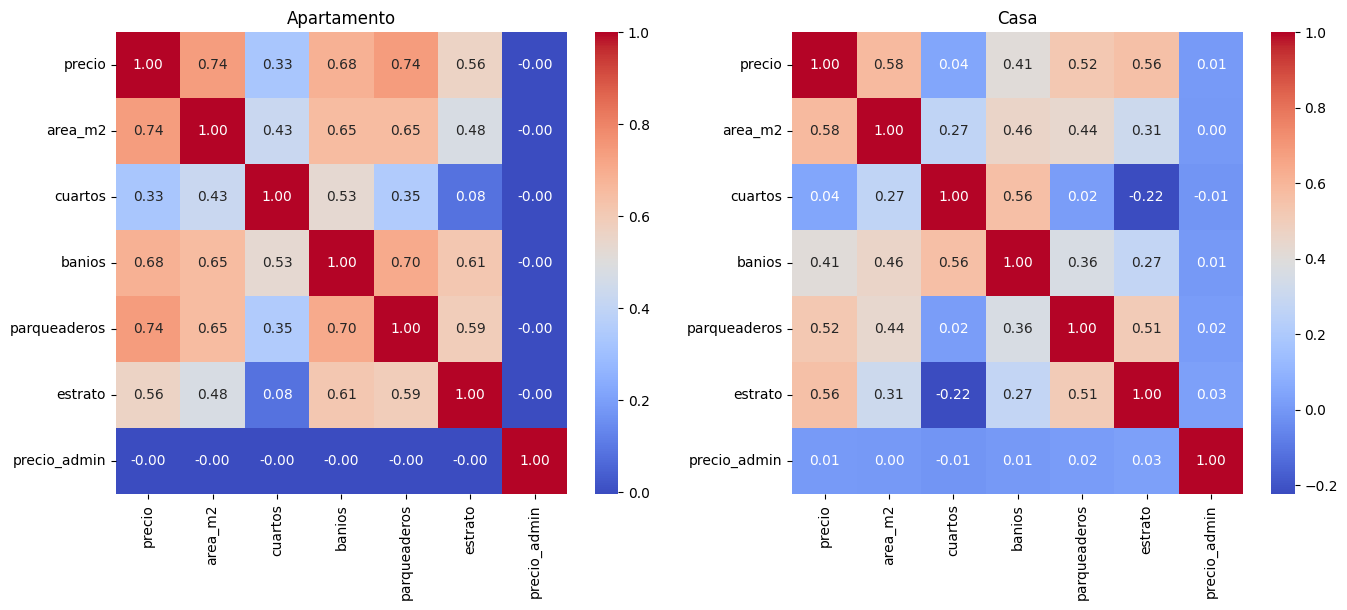

In [28]:
cols = ['precio', 'area_m2', 'cuartos', 'banios', 'parqueaderos', 'estrato', 'precio_admin']                                

fig, axes = plt.subplots(1, 2, figsize=(16, 6))                                                             
   
sns.heatmap(df[df['tipo_propiedad']=='apartamento'][cols].corr(),                                           
            annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0])
axes[0].set_title("Apartamento")                                                                            
                                                                                                            
sns.heatmap(df[df['tipo_propiedad']=='casa'][cols].corr(),                                                  
            annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])                                             
axes[1].set_title("Casa")


## 9. Price Distribution & Outlier Treatment                                                                

### 9.1 Lower Bound — Minimum Viable Price                                                                  

The price distribution reveals listings below 80,000,000 COP, which are implausible for residential properties in Bogotá's current market. As a reference point, the minimum
price for a VIS/VIP (*Vivienda de Interés Social/Prioritario*) unit — the lowest regulated housing category in Colombia — stands at approximately 230,000,000 COP. 
                                                                                                            
> Source: [Metro Cuadrado — Precio tope VIS 2024](https://www.metrocuadrado.com/noticias/actualidad/subio-el-precio-tope-de-la-vivienda-de-interes-social-3723)
                                                                                                            
Additionally, the DANE *Índice de Precios de la Vivienda Nueva (IPVN)* confirms a sustained upward trend in new housing prices, further supporting the removal of sub-threshold listings as data entry errors rather than legitimate market records.                          
                                                                                                            
> Source: [DANE — IPVN](https://www.dane.gov.co/index.php/estadisticas-por-tema/precios-y-costos/indice-de-precios-de-la-vivienda-nueva-ipvn) 
                                                                                                            
Records below 80,000,000 COP are dropped from the dataset.

In [29]:
df[df['precio'] <= 80000000]

,id,area_m2,cuartos,estrato,parqueaderos,banios,precio,precio_m2,precio_admin,tipo_propiedad,barrio,ciudad,lat,lon,direccion,antiguedad,descripcion,geometry
37623,71815136-65b2-40bb-8b1b-73f3207fe025,156,3,5,3.0,4.0,6500000,41666.67,740000.0,apartamento,la-felicidad,bogota,4.659096,-74.127060,CL 21 # 78 - 99,menor a 1 año,"ARRIENDO Apartamento Duplex de 156 mt2, tiene ...",POINT (2759195.617 -9155235.067)
37630,053fb695-2912-4fb9-8e31-8659a18ff878,80,3,4,1.0,2.0,1850000,23125.00,261000.0,apartamento,el-dorado-industrial,bogota,4.724648,-74.133487,CALLE 78B 120A- 55,1 a 8 años,GRAN GRANADA HERMOSO APARTAMENTO PISO 12 SALA ...,POINT (2758886.521 -9157420.42)
37634,1a9cd248-3046-4920-b670-85fa6fc38451,40,2,2,1.0,1.0,80000000,2000000.00,0.0,apartamento,virrey,bogota,4.672133,-74.052079,El virrey,9 a 15 años,SE VENDE HERMOSO APARTAMENTO EN 4TO PISO. CONJ...,POINT (2767787.608 -9153879.998)
37639,12249be1-5050-48e7-a373-c1eabfe38314,98,3,3,1.0,2.0,37000000,377551.02,280000.0,apartamento,centro-industrial,bogota,4.641000,-74.114000,Av Carrera 68 #18 -9 SUR,más de 30 años,Espectacular apartamento con excelente ilumina...,POINT (2760560.797 -9154366.061)
37640,bbf7670d-2005-4430-8ccb-4cbd805a8cdb,250,3,5,2.0,3.0,8600000,34400.00,1300000.0,apartamento,usaquen,bogota,4.703060,-74.027448,Calle 127A # 5C - 41,16 a 30 años,Presentamos en cerros orientales - Bella Suiza...,POINT (2770782.845 -9154268.166)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38134,8c3e7782-90ea-49bf-8042-83fd55362df9,50,3,3,1.0,1.0,8888888,177777.76,0.0,apartamento,centro-comercial-portal-80,bogota,4.714867,-74.109425,Centro Comercial Portal 80,sin especificar,🎁 🆂🆄🅿🅴🆁 🅿🆁🅾🅼🅾 💲185.000.000❗ ✅ Venta directa 🛡️...,POINT (2761554.398 -9156554.393)
38142,32e873b5-8e27-453a-9455-42ec765b0512,72,4,1,1.0,2.0,50000000,694444.44,0.0,casa,tihuaque,bogota,5.026025,-74.030014,cra 12 f # 60_09,1 a 8 años,Vendo casa 612 50 millones negociable agua luz...,POINT (2772544.298 -9164426.775)
37962,28c14395-2df7-44ff-8993-eeb1aa65ade1,50,2,2,1.0,1.0,80000000,1600000.00,0.0,apartamento,parque-ambiental-cantarrana,bogota,0.000000,0.000000,Cantarrana,sin especificar,Apartamento en primer piso ubicado en cantarra...,POINT (13669113.61 491767.534)
37974,044c820b-d351-4c84-aa0c-f99a8a2ff9a7,40,2,2,1.0,1.0,70000000,1750000.00,0.0,apartamento,calvo-sur,bogota,4.584304,-74.078636,Carrera 4 1- 46,sin especificar,Se vende excelente apartamento ubicado en la c...,POINT (2764205.848 -9151768.524)


In [30]:
df[df['precio'] >= 10000000000] 

,id,area_m2,cuartos,estrato,parqueaderos,banios,precio,precio_m2,precio_admin,tipo_propiedad,barrio,ciudad,lat,lon,direccion,antiguedad,descripcion,geometry
17701,0689a7d2-f36f-497a-8c21-38c93e1b1b54,843,3,6,6.0,4.0,17000000000,2.016607e+07,0.0,casa,el-refugio,bogota,4.667487,-74.043473,KR 4 87 31,9 a 15 años,Tenemos el placer de presentarte en venta una ...,POINT (2768734.359 -9153532.909)
17753,b207f723-1374-4b29-9c08-fecb94047321,120,3,6,2.0,4.0,13000000000,1.083333e+08,0.0,apartamento,los-rosales,bogota,4.659000,-74.046997,Carrera 1 Este # 78 911559782,1 a 8 años,Este es un penthouse dúplex de diseño con zona...,POINT (2768279.564 -9153350.819)
17785,dc8f65de-9c70-40d6-b28a-63600d98ee80,1800,7,6,2.0,9.0,12000000000,6.666667e+06,1500000.0,casa,torca-rural-i,bogota,4.819793,-74.031286,Avenida 7 245 60 CA28,9 a 15 años,Código 32WAS45158 - Hermosa Propiedad en Venta...,POINT (2771095.838 -9158006.273)
18042,5ffa5dda-d505-416a-a9da-2dfabc1444ef,1050,4,6,1.0,5.0,12000000000,1.142857e+07,8400000.0,apartamento,chico-alto,bogota,4.668030,-74.043545,CARRERA 3 93- 62,9 a 15 años,Espectacular apartamento hacia los cerros orie...,POINT (2768729.696 -9153551.551)
18058,d52fd6c8-9de2-4d50-a327-2c532384b248,888,4,6,4.0,6.0,12000000000,1.351351e+07,600000.0,casa,usaquen,bogota,4.691297,-74.030836,Cra. 3 #109-68,16 a 30 años,Se vende ESPECTACULAR casa en Santa Ana Orien...,POINT (2770322.47 -9153979.963)
18390,2e2e1064-ea1e-4da4-b177-6cb049bcdf30,925,6,6,8.0,8.0,13000000000,1.405405e+07,650000.0,casa,santa-ana-oriental,bogota,4.688000,-74.027000,Calle 110B #0-104168639,más de 30 años,Amplia casa con jardín y terraza para venta en...,POINT (2770736.525 -9153787.005)
18471,ffd3dbd8-619b-4e06-b4c0-446626e94cd8,2400,6,6,4.0,4.0,10000000000,4.166667e+06,0.0,casa,ciudad-salitre,bogota,4.648594,-74.104466,TORCA,1 a 8 años,1ER NIVEL: Doble sala social con chimenea a ga...,POINT (2761691.359 -9154377.818)
18554,214a3535-5a2f-48dd-bc8c-171cacca5d7d,500,6,6,4.0,4.0,10000000000,2.000000e+07,0.0,casa,salitre-oriental,bogota,4.648594,-74.104466,TORCA,1 a 8 años,1ER NIVEL: Doble sala social con chimenea a ga...,POINT (2761691.359 -9154377.818)
18583,397a098c-bef5-4b83-ba9c-b10605008a9f,1450,1,5,2.0,1.0,18000000000,1.241379e+07,0.0,casa,centro-comercial-la-plazuela,cartagena,4.704210,-74.053841,CARRERA 35 3- 30,más de 30 años,CASA UBICADO EN LA PLAZA DE SANTO DOMINGO DIV...,POINT (2767794.436 -9154922.094)
18625,9cf28078-51a4-41ba-a702-02f195743861,676,6,6,5.0,6.0,10000000000,1.479290e+07,4546700.0,apartamento,la-cabrera,bogota,4.671000,-74.052000,Calle 87 #12-794101718,9 a 15 años,Exclusivo penthouse con terraza para venta en ...,POINT (2767789.299 -9153842.8)


### 9.2 Upper Bound — Ultra-Luxury Segment                                                                  

The right tail of the log-scale distribution extends beyond 10,000,000,000 COP (~2.7M USD), representing ultra-luxury properties. This segment accounts for fewer
than 50 listings in the dataset — insufficient for the model to reliably learn the price dynamics of this tier.
                                                                                                            
These records introduce high variance without providing enough signal, which can negatively impact model performance across the broader market. They are flagged as
candidates for removal prior to training, or alternatively treated as a separate segment outside the model's prediction scope.

In [31]:
df = df[(df['precio'] >= 80000000) & (df['precio'] < 10000000000)] 

### 9.3 Price Distribution by Property Type                                                                 
                                                                                                              
The boxplot confirms the price gap between property types:                                                  
   
- **Houses** tend to command higher prices than apartments, driven primarily by total built area — a house can easily reach 200–300 m² across multiple floors, roughly 3x
the median apartment size of ~80 m². The wider IQR reflects the high variance discussed in section 8.2: house prices are more sensitive to location than to physical
characteristics alone.                                                                                    
                
- **Apartments** show a tighter distribution with a median price around 500,000,000 COP, consistent with the 80 m² median area benchmark from CAMACOL. The narrower IQR suggests that apartment prices are more predictable from structural features — area, stratum, and parking — than house prices.
                                                                                                            
Given these distinct distributions, `tipo_propiedad` will be included as a categorical feature in the model, allowing the algorithm to learn different price dynamics for each property type within a single model.

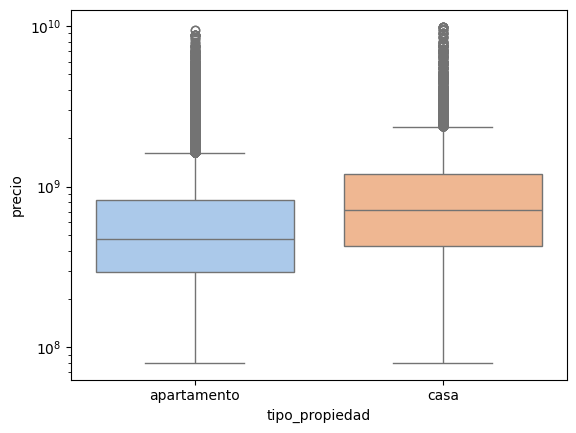

In [32]:
sns.boxplot(x="tipo_propiedad", y="precio", data=df, hue="tipo_propiedad", legend=False, palette="pastel")
plt.yscale("log")

### 9.4 Log Transformation of the Target Variable                                                           

The price range spans from ~100,000,000 COP to over 5,000,000,000 COP — a difference of nearly two orders of magnitude. In its original scale, the distribution is heavily
right-skewed, which violates the assumptions of most regression models and makes it difficult to minimize error uniformly across price segments. 
                                                                                                            
Applying a log transformation (`np.log`) compresses the range and produces a near-normal distribution, as confirmed by the right panel of the histogram above. This allows the model to learn price relationships more effectively across all segments — from affordable units to the premium tier — without being dominated by the variance of high-value outliers.                                                                                     
                                                                                                              
During inference, predictions are returned to the original COP scale via the inverse transformation (`np.exp`).

Text(0.5, 1.0, 'Price Distribution (Log Scale)')

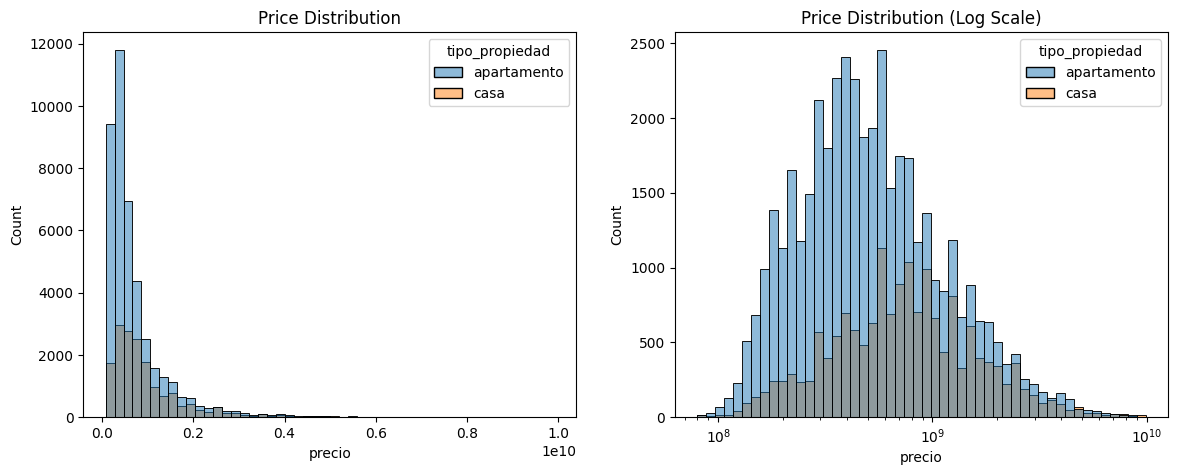

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                                             
                                                                                                              
sns.histplot(data=df, x="precio", hue="tipo_propiedad", bins=50, ax=axes[0])                                
axes[0].set_title("Price Distribution")
                                                                                                            
sns.histplot(data=df, x="precio", hue="tipo_propiedad", bins=50, log_scale=True, ax=axes[1])                
axes[1].set_title("Price Distribution (Log Scale)")


## 10. EDA Summary — Features Carried Forward

After data quality enforcement, imputation, and outlier treatment, the dataset is ready for feature engineering. The following features are retained:

| Feature | Notes |
|---|---|
| `area_m2` | Bounded to 18–5,000 m² |
| `cuartos` | Imputed via area buckets |
| `banios` | Imputed via estrato + tipo_propiedad median |
| `parqueaderos` | Imputed via tipo_propiedad + area_bin median |
| `tipo_propiedad` | Two classes: casa, apartamento |
| `estrato` | Spatially imputed via BallTree KNN |
| `lat`, `lon` | Used to derive H3 index and IDECA neighborhood in feature engineering |
| `precio` | Target variable — log-transformed for training |

Dropped features: `piso` / `num_pisos` / `piso_torre` (>25% nulls), `precio_admin` (no correlation), broker fields, timestamps, and URL.

In [34]:
df.to_csv('data/feature_engineering.csv', index=False)